In [110]:
import numpy as np  
import pandas as pd  
import matplotlib.pyplot as plt
import seaborn as sns 

In [111]:
df=pd.read_csv(r"C:\projek ML pribadi\ML_analis 3\AI_Student_Life_Pakistan_2026.csv")
df.head(3)

,Student_ID,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,1,15,Female,School,Lahore,ChatGPT,0.8,Writing,Slight Decline,Low
1,2,15,Female,College,Multan,Copilot,1.6,Learning,No Change,High
2,3,16,Female,College,Multan,ChatGPT,1.8,Research,Improved,Low


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Student_ID          100 non-null    int64  
 1   Age                 100 non-null    int64  
 2   Gender              100 non-null    object 
 3   Education_Level     100 non-null    object 
 4   City                100 non-null    object 
 5   AI_Tool_Used        100 non-null    object 
 6   Daily_Usage_Hours   100 non-null    float64
 7   Purpose             100 non-null    object 
 8   Impact_on_Grades    100 non-null    object 
 9   Satisfaction_Level  100 non-null    object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.9+ KB


In [113]:
df.value_counts()

Student_ID  Age  Gender  Education_Level  City        AI_Tool_Used  Daily_Usage_Hours  Purpose   Impact_on_Grades  Satisfaction_Level
1           15   Female  School           Lahore      ChatGPT       0.8                Writing   Slight Decline    Low                   1
64          22   Male    School           Faisalabad  Copilot       3.2                Homework  No Change         Medium                1
74          22   Male    School           Multan      Notion AI     4.7                Writing   Improved          Low                   1
73          15   Male    University       Faisalabad  Notion AI     4.7                Homework  No Change         Low                   1
72          19   Female  College          Faisalabad  Gemini        5.8                Learning  No Change         High                  1
                                                                                                                                        ..
31          15   Male    Univers

In [114]:
df.describe()

,Student_ID,Age,Daily_Usage_Hours
count,100.000000,100.000000,100.000000
mean,50.500000,19.380000,3.064000
std,29.011492,3.296095,1.564862
min,1.000000,15.000000,0.500000
25%,25.750000,16.000000,1.800000
50%,50.500000,19.000000,3.200000
75%,75.250000,22.000000,4.300000
max,100.000000,25.000000,5.900000


In [115]:
df.isnull().sum()

Student_ID            0
Age                   0
Gender                0
Education_Level       0
City                  0
AI_Tool_Used          0
Daily_Usage_Hours     0
Purpose               0
Impact_on_Grades      0
Satisfaction_Level    0
dtype: int64

In [116]:
df.duplicated().sum()

0

In [117]:
df.nunique()

Student_ID            100
Age                    11
Gender                  2
Education_Level         3
City                    5
AI_Tool_Used            5
Daily_Usage_Hours      44
Purpose                 5
Impact_on_Grades        3
Satisfaction_Level      3
dtype: int64

Menghapus Kolom

In [118]:
df=df.drop('Student_ID', axis=1)

# EDA

<Axes: xlabel='Impact_on_Grades', ylabel='count'>

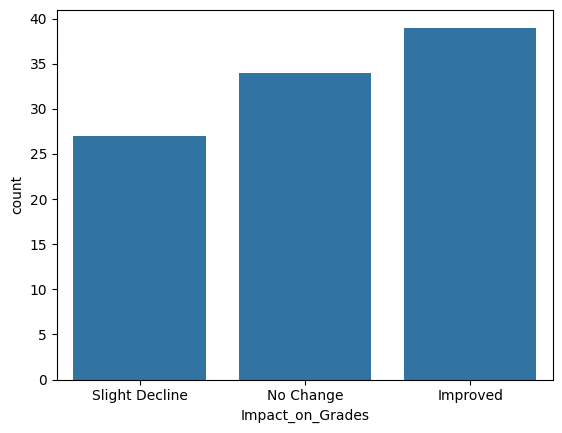

In [119]:
sns.countplot(data=df, x="Impact_on_Grades")

<Axes: xlabel='Impact_on_Grades', ylabel='Daily_Usage_Hours'>

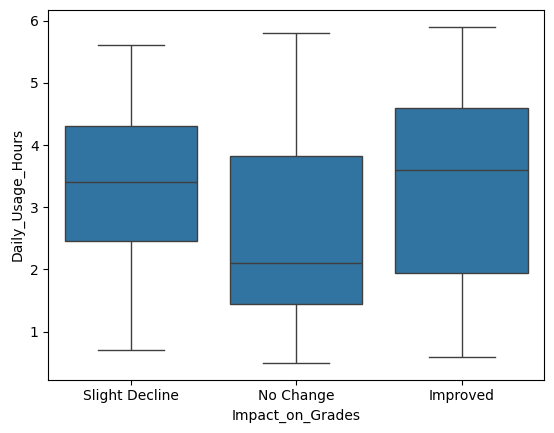

In [120]:
sns.boxplot(
    data=df,
    x="Impact_on_Grades",
    y="Daily_Usage_Hours"
)

<Axes: xlabel='Purpose', ylabel='count'>

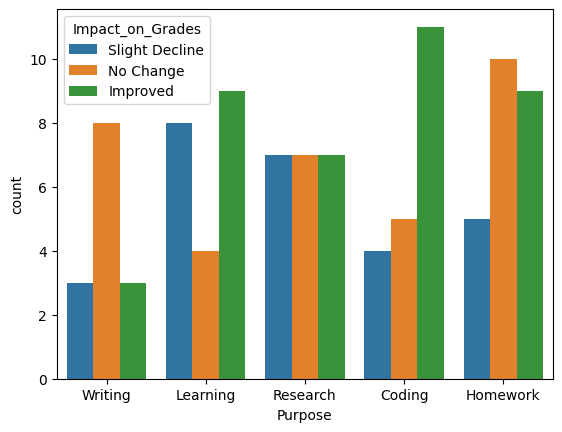

In [121]:
sns.countplot(
    data=df,
    x='Purpose',
    hue='Impact_on_Grades'
)

Lihat tabel frekuensi hubungan antar kategori.

In [122]:
pd.crosstab(df['Purpose'], df['Impact_on_Grades'])

Impact_on_Grades,Improved,No Change,Slight Decline
Purpose,,,
Coding,11,5,4
Homework,9,10,5
Learning,9,4,8
Research,7,7,7
Writing,3,8,3


Lihat dengan presentase

In [123]:
pd.crosstab(
    df['Purpose'],
    df['Impact_on_Grades'],
    normalize='index'
) * 100

Impact_on_Grades,Improved,No Change,Slight Decline
Purpose,,,
Coding,55.000000,25.000000,20.000000
Homework,37.500000,41.666667,20.833333
Learning,42.857143,19.047619,38.095238
Research,33.333333,33.333333,33.333333
Writing,21.428571,57.142857,21.428571


In [124]:
df

,Age,Gender,Education_Level,City,AI_Tool_Used,Daily_Usage_Hours,Purpose,Impact_on_Grades,Satisfaction_Level
0,15,Female,School,Lahore,ChatGPT,0.8,Writing,Slight Decline,Low
1,15,Female,College,Multan,Copilot,1.6,Learning,No Change,High
2,16,Female,College,Multan,ChatGPT,1.8,Research,Improved,Low
3,22,Male,University,Karachi,ChatGPT,4.2,Learning,Improved,High
4,16,Male,School,Multan,ChatGPT,1.8,Coding,Improved,Medium
...,...,...,...,...,...,...,...,...,...
95,16,Female,School,Multan,Grammarly,5.0,Learning,Slight Decline,Medium
96,25,Female,School,Faisalabad,Gemini,1.9,Writing,No Change,Medium
97,17,Female,College,Faisalabad,Gemini,2.9,Writing,No Change,Low
98,15,Female,College,Lahore,Notion AI,3.6,Homework,Slight Decline,High


# Mapping Data Ordinal Kategorikal

In [125]:
mapping = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}
df['Satisfaction_Level'] = df['Satisfaction_Level'].map(mapping)

In [126]:
mapping = {
    "Slight Decline": 0,
    "No Change": 1,
    "Improved": 2
}
df['Impact_on_Grades'] = df['Impact_on_Grades'].map(mapping)

In [127]:
mapping ={
    'School': 1,
    'College': 2,
    'University': 3
}
df['Education_Level'] = df['Education_Level'].map(mapping)

# encoding data non-ordinal

In [128]:
from sklearn.preprocessing import OneHotEncoder


# One-hot encoding
df= pd.get_dummies(
    df,
    columns=['Gender', 'City', 'AI_Tool_Used', 'Purpose'],
    drop_first=True
)

print(df.head())

   Age  Education_Level  Daily_Usage_Hours  Impact_on_Grades  \
0   15                1                0.8                 0   
1   15                2                1.6                 1   
2   16                2                1.8                 2   
3   22                3                4.2                 2   
4   16                1                1.8                 2   

   Satisfaction_Level  Gender_Male  City_Islamabad  City_Karachi  City_Lahore  \
0                   1        False           False         False         True   
1                   3        False           False         False        False   
2                   1        False           False         False        False   
3                   3         True           False          True        False   
4                   2         True           False         False        False   

   City_Multan  AI_Tool_Used_Copilot  AI_Tool_Used_Gemini  \
0        False                 False                False   
1     

 Cek distribusi, outlier dan perilaku pengguna ekstrem

In [129]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

Pisahkan feature dan target

In [130]:
X = df.drop("Impact_on_Grades", axis=1) 
y = df["Impact_on_Grades"]

In [131]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [132]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [133]:
y_pred = model.predict(X_test)

# Evaluasi

In [134]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.38      0.60      0.46         5
           1       0.67      0.29      0.40         7
           2       0.67      0.75      0.71         8

    accuracy                           0.55        20
   macro avg       0.57      0.55      0.52        20
weighted avg       0.59      0.55      0.54        20



# Cek confussion matrix

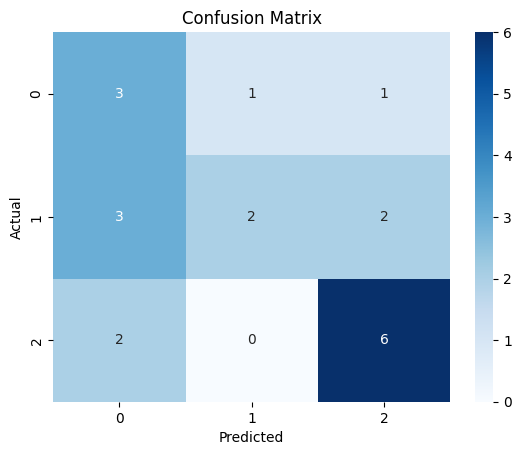

In [135]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Feature importence

In [136]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print(importance.head(10))

                   Feature  Coefficient
14        Purpose_Learning     0.600816
6             City_Karachi     0.501643
15        Purpose_Research     0.489991
11  AI_Tool_Used_Grammarly     0.487770
16         Purpose_Writing     0.163355
4              Gender_Male     0.134707
2        Daily_Usage_Hours     0.130230
3       Satisfaction_Level     0.119572
13        Purpose_Homework     0.040955
7              City_Lahore     0.017858


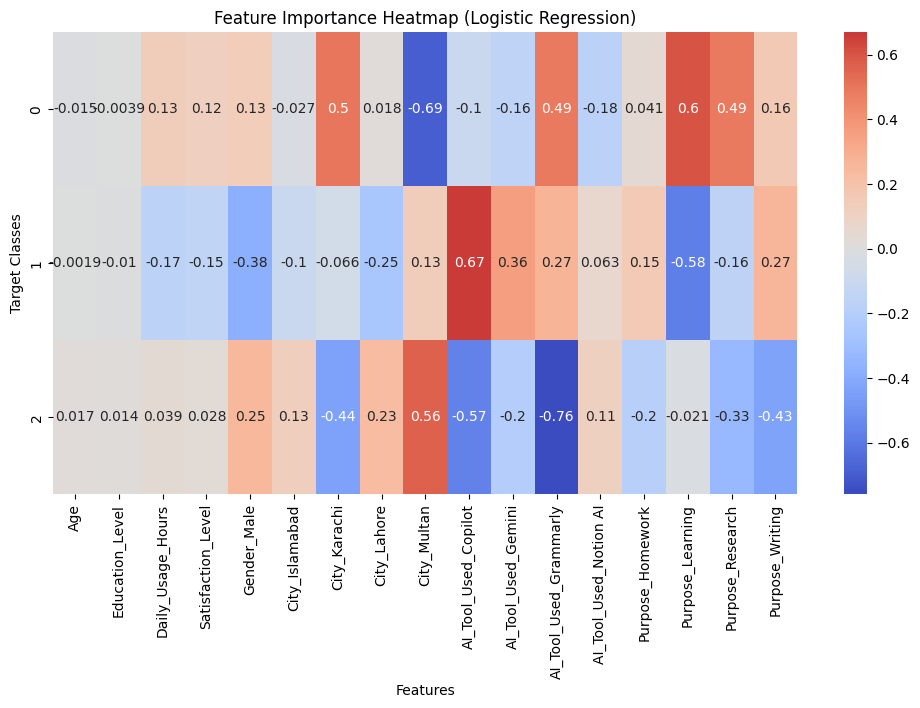

In [137]:
# Feature Importance Heatmap

importance = pd.DataFrame(
    model.coef_,
    columns=X.columns,
    index=model.classes_
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    importance,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Feature Importance Heatmap (Logistic Regression)")
plt.xlabel("Features")
plt.ylabel("Target Classes")

plt.show()